# Glu-Fibrinopeptide B — Centrix m/z Accuracy Assessment

Infusion of Glu-Fibrinopeptide B (EGVNDNEEGFFSAR, [M+2H]²⁺ = 785.842) collected
on a Fusion Lumos LIT at three scan rates:

| File | Scan Rate | Grid Spacing |
|------|-----------|-------------|
| Normal | 33 kTh/s | 1/30 Th |
| Rapid | 67 kTh/s | 1/15 Th |
| Turbo | 125 kTh/s | 1/8 Th |

Each file has ~2000 MS2 spectra with HCD fragmentation at 27 NCE.

We compare Centrix centroided m/z values against theoretical singly-charged
b and y ion masses to assess m/z accuracy.

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from pyteomics import mzml
from pathlib import Path

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "figure.dpi": 120,
    "font.size": 10,
})

# --- Theoretical b and y ions for EGVNDNEEGFFSAR (singly charged) ---
# Sequence: E G V N D N E E G F F S A R
#           1 2 3 4 5 6 7 8 9 10 11 12 13

b_ions = {
    "b1":  130.0499,  # E
    "b2":  187.0713,  # G
    "b3":  286.1397,  # V
    "b4":  400.1827,  # N
    "b5":  515.2096,  # D
    "b6":  629.2525,  # N
    "b7":  758.2951,  # E
    "b8":  887.3377,  # E
    "b9":  944.3592,  # G
    "b10": 1091.4276, # F
    "b11": 1238.4960, # F
    "b12": 1325.5280, # S
    "b13": 1396.5651, # A
}

y_ions = {
    "y1":  175.1190,  # R (from A)
    "y2":  246.1561,  # A (from S)
    "y3":  333.1881,  # S (from F)
    "y4":  480.2565,  # F (from F)
    "y5":  627.3249,  # F (from G)
    "y6":  684.3464,  # G (from E)
    "y7":  813.3890,  # E (from E)
    "y8":  942.4316,  # E (from N)
    "y9":  1056.4745, # N (from D)
    "y10": 1171.5014, # D (from N)
    "y11": 1285.5444, # N (from V)
    "y12": 1384.6128, # V (from G)
    "y13": 1441.6342, # G (from E)
}

# Combine and filter to scan range (200–1400 m/z)
SCAN_LO, SCAN_HI = 200.0, 1400.0
all_ions = {}
for name, mz in {**b_ions, **y_ions}.items():
    if SCAN_LO <= mz <= SCAN_HI:
        all_ions[name] = mz

# Sort by m/z for consistent ordering
all_ions = dict(sorted(all_ions.items(), key=lambda x: x[1]))
print(f"{len(all_ions)} ions in scan range ({SCAN_LO}–{SCAN_HI} m/z):")
for name, mz in all_ions.items():
    print(f"  {name:>4s}: {mz:.4f}")

22 ions in scan range (200.0–1400.0 m/z):
    y2: 246.1561
    b3: 286.1397
    y3: 333.1881
    b4: 400.1827
    y4: 480.2565
    b5: 515.2096
    y5: 627.3249
    b6: 629.2525
    y6: 684.3464
    b7: 758.2951
    y7: 813.3890
    b8: 887.3377
    y8: 942.4316
    b9: 944.3592
    y9: 1056.4745
   b10: 1091.4276
   y10: 1171.5014
   b11: 1238.4960
   y11: 1285.5444
   b12: 1325.5280
   y12: 1384.6128
   b13: 1396.5651


In [44]:
# --- File paths ---
DATA_DIR = Path("..") / "example-data" / "glufib-infusion"
OUTPUT_DIR = DATA_DIR / "centrix-output"
THERMO_DIR = DATA_DIR / "Thermo-Centroid"

FILES = {
    "Normal (33 kTh/s)": {
        "profile": DATA_DIR / "Crucios_Glufib_LIT_27HCD_Normal_z2_profile.mzML",
        "centrix": OUTPUT_DIR / "Crucios_Glufib_LIT_27HCD_Normal_z2_profile.centrix.mzML",
        "thermo": THERMO_DIR / "Crucios_Glufib_LIT_27HCD_Normal_z2_Thermo_Centroid.mzML",
    },
    "Rapid (67 kTh/s)": {
        "profile": DATA_DIR / "Crucios_Glufib_LIT_27HCD_Rapid_z2_profile.mzML",
        "centrix": OUTPUT_DIR / "Crucios_Glufib_LIT_27HCD_Rapid_z2_profile.centrix.mzML",
        "thermo": THERMO_DIR / "Crucios_Glufib_LIT_27HCD_Rapid_z2_Thermo_Centroid.mzML",
    },
    "Turbo (125 kTh/s)": {
        "profile": DATA_DIR / "Crucios_Glufib_LIT_27HCD_Turbo_z2_profile.mzML",
        "centrix": OUTPUT_DIR / "Crucios_Glufib_LIT_27HCD_Turbo_z2_profile.centrix.mzML",
        "thermo": THERMO_DIR / "Crucios_Glufib_LIT_27HCD_Turbo_z2_Thermo_Centroid.mzML",
    },
}

# Verify files exist
for label, paths in FILES.items():
    for kind, p in paths.items():
        status = "OK" if p.exists() else "MISSING"
        print(f"  [{status}] {label} {kind}: {p.name}")

  [OK] Normal (33 kTh/s) profile: Crucios_Glufib_LIT_27HCD_Normal_z2_profile.mzML
  [OK] Normal (33 kTh/s) centrix: Crucios_Glufib_LIT_27HCD_Normal_z2_profile.centrix.mzML
  [OK] Normal (33 kTh/s) thermo: Crucios_Glufib_LIT_27HCD_Normal_z2_Thermo_Centroid.mzML
  [OK] Rapid (67 kTh/s) profile: Crucios_Glufib_LIT_27HCD_Rapid_z2_profile.mzML
  [OK] Rapid (67 kTh/s) centrix: Crucios_Glufib_LIT_27HCD_Rapid_z2_profile.centrix.mzML
  [OK] Rapid (67 kTh/s) thermo: Crucios_Glufib_LIT_27HCD_Rapid_z2_Thermo_Centroid.mzML
  [OK] Turbo (125 kTh/s) profile: Crucios_Glufib_LIT_27HCD_Turbo_z2_profile.mzML
  [OK] Turbo (125 kTh/s) centrix: Crucios_Glufib_LIT_27HCD_Turbo_z2_profile.centrix.mzML
  [OK] Turbo (125 kTh/s) thermo: Crucios_Glufib_LIT_27HCD_Turbo_z2_Thermo_Centroid.mzML


In [45]:
# --- Helper functions ---

def load_spectrum(path, index):
    """Load a single spectrum by 0-based index."""
    reader = mzml.MzML(str(path))
    spec = reader.get_by_index(index)
    return spec["m/z array"], spec["intensity array"]

def crop(mz, intensity, center, halfwidth=1.5):
    """Crop arrays to center ± halfwidth."""
    mask = (mz >= center - halfwidth) & (mz <= center + halfwidth)
    return mz[mask], intensity[mask]

def nearest_centroid(cx_mz, cx_int, target_mz, tol=0.5):
    """Find the centroid nearest to target_mz within tolerance."""
    if len(cx_mz) == 0:
        return None, None
    diffs = np.abs(cx_mz - target_mz)
    idx = np.argmin(diffs)
    if diffs[idx] <= tol:
        return cx_mz[idx], cx_int[idx]
    return None, None

In [46]:
# --- Select top 10 most intense fragment ions, split into two groups ---
# Use a representative spectrum (scan #100) from the Normal file to rank ions by intensity.

ref_mz, ref_int = load_spectrum(FILES["Normal (33 kTh/s)"]["profile"], 99)

ion_intensities = {}
for name, theo_mz in all_ions.items():
    mask = (ref_mz >= theo_mz - 0.3) & (ref_mz <= theo_mz + 0.3)
    if mask.any():
        ion_intensities[name] = float(np.max(ref_int[mask]))
    else:
        ion_intensities[name] = 0.0

# Pick top 10 by intensity
top10_names = sorted(ion_intensities, key=ion_intensities.get, reverse=True)[:10]
top10 = {n: all_ions[n] for n in sorted(top10_names, key=lambda n: all_ions[n])}

# Split: top 5 by intensity → group A, next 5 → group B (each sorted by m/z)
top5_names = sorted(ion_intensities, key=ion_intensities.get, reverse=True)[:5]
next5_names = sorted(ion_intensities, key=ion_intensities.get, reverse=True)[5:10]
top5 = {n: all_ions[n] for n in sorted(top5_names, key=lambda n: all_ions[n])}
next5 = {n: all_ions[n] for n in sorted(next5_names, key=lambda n: all_ions[n])}

print("Top 5 ions (by intensity, sorted by m/z):")
for name, mz in top5.items():
    print(f"  {name:>5s}: {mz:.4f}  (intensity {ion_intensities[name]:.0f})")
print("\nIons 6–10 (by intensity, sorted by m/z):")
for name, mz in next5.items():
    print(f"  {name:>5s}: {mz:.4f}  (intensity {ion_intensities[name]:.0f})")
print(f"\nDropped: {sorted(set(all_ions) - set(top10), key=lambda n: all_ions[n])}")

Top 5 ions (by intensity, sorted by m/z):
     y3: 333.1881  (intensity 182927)
     y4: 480.2565  (intensity 228339)
     y6: 684.3464  (intensity 314525)
     y7: 813.3890  (intensity 290054)
    y11: 1285.5444  (intensity 205141)

Ions 6–10 (by intensity, sorted by m/z):
     y2: 246.1561  (intensity 86980)
     y5: 627.3249  (intensity 91200)
     y8: 942.4316  (intensity 142468)
     y9: 1056.4745  (intensity 176632)
    y10: 1171.5014  (intensity 179900)

Dropped: ['b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'b9', 'b10', 'b11', 'b12', 'y12', 'b13']


## 1. Profile + Centroids Around Each Fragment (Spectrum #100)

For each theoretical b/y ion, we plot ±1.5 Th of the profile data with:
- **Blue line**: raw profile trace
- **Red dashed line**: theoretical m/z
- **Green diamonds**: Centrix centroids in the window
- **Orange triangles**: Thermo onboard centroids in the window

Shown for all three scan rates side by side.

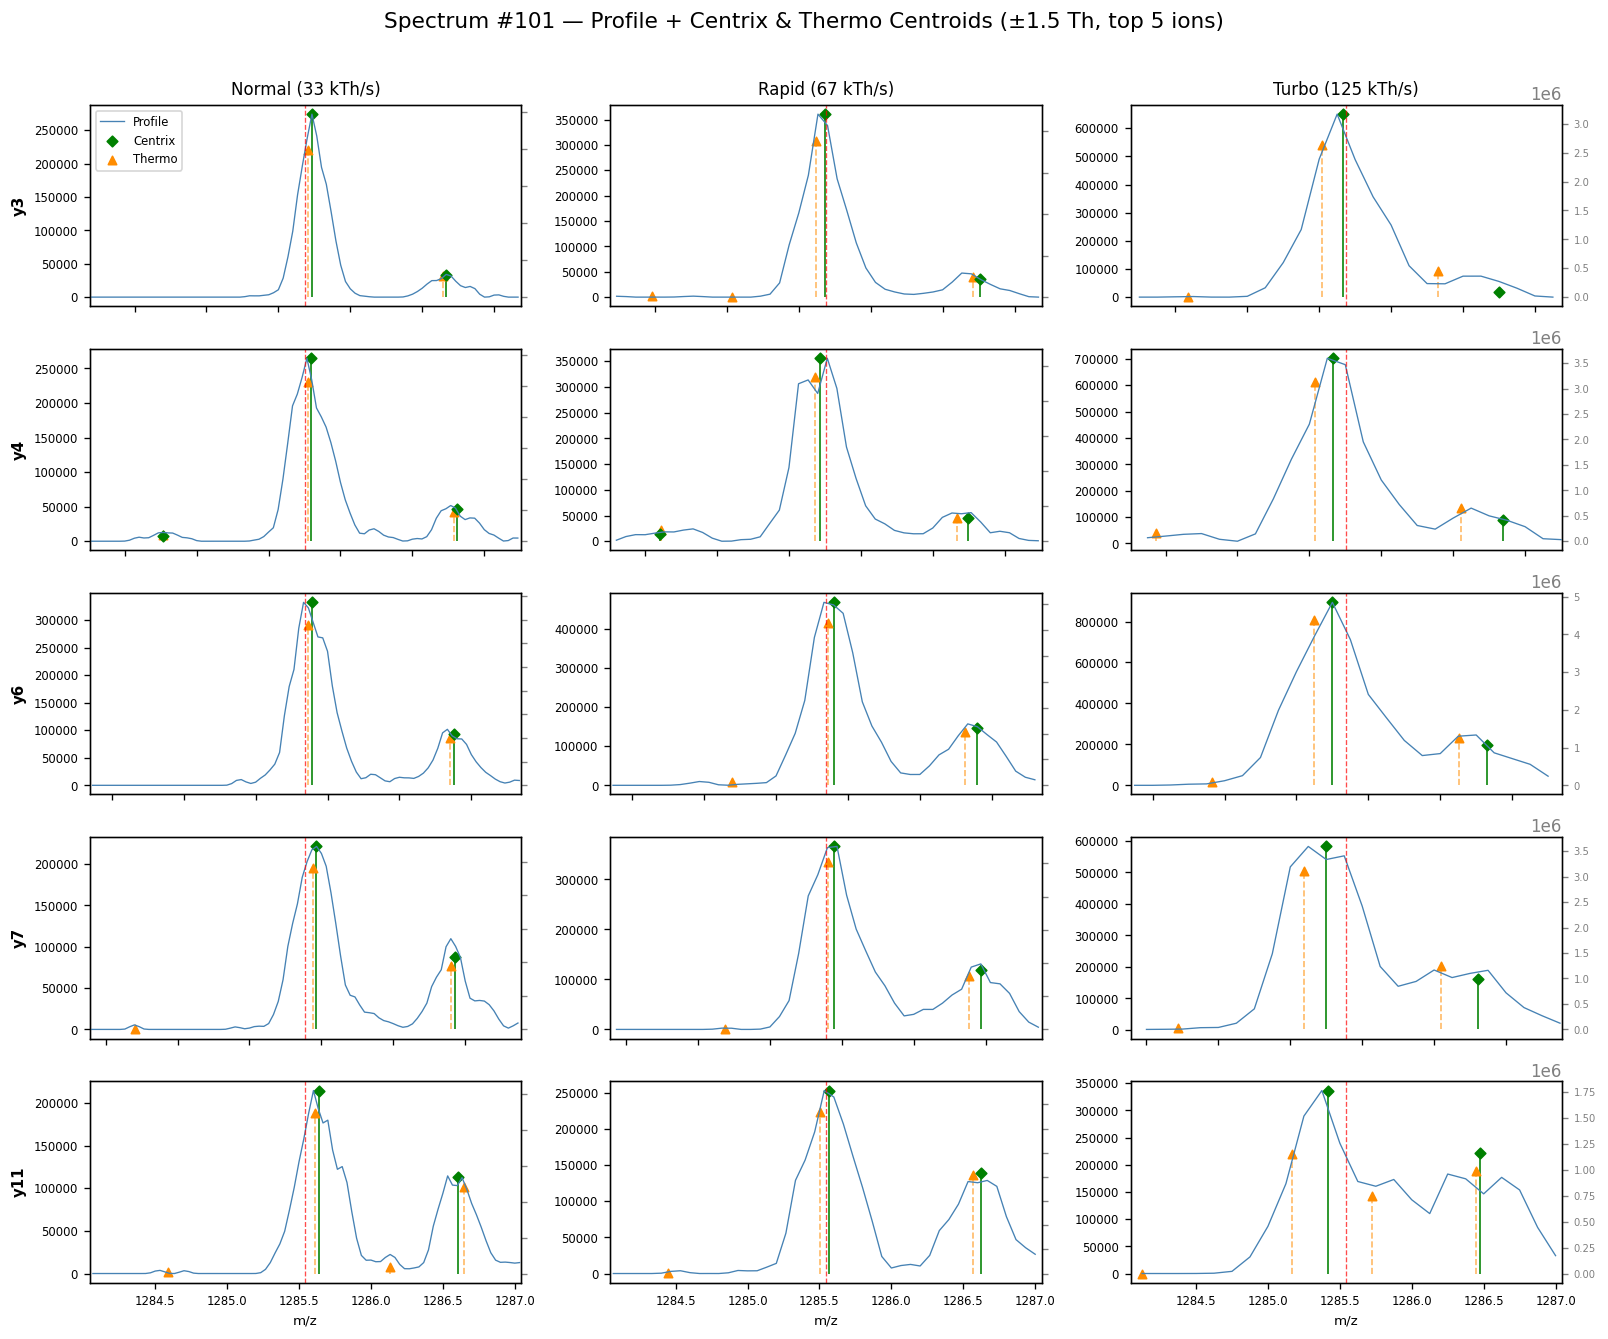

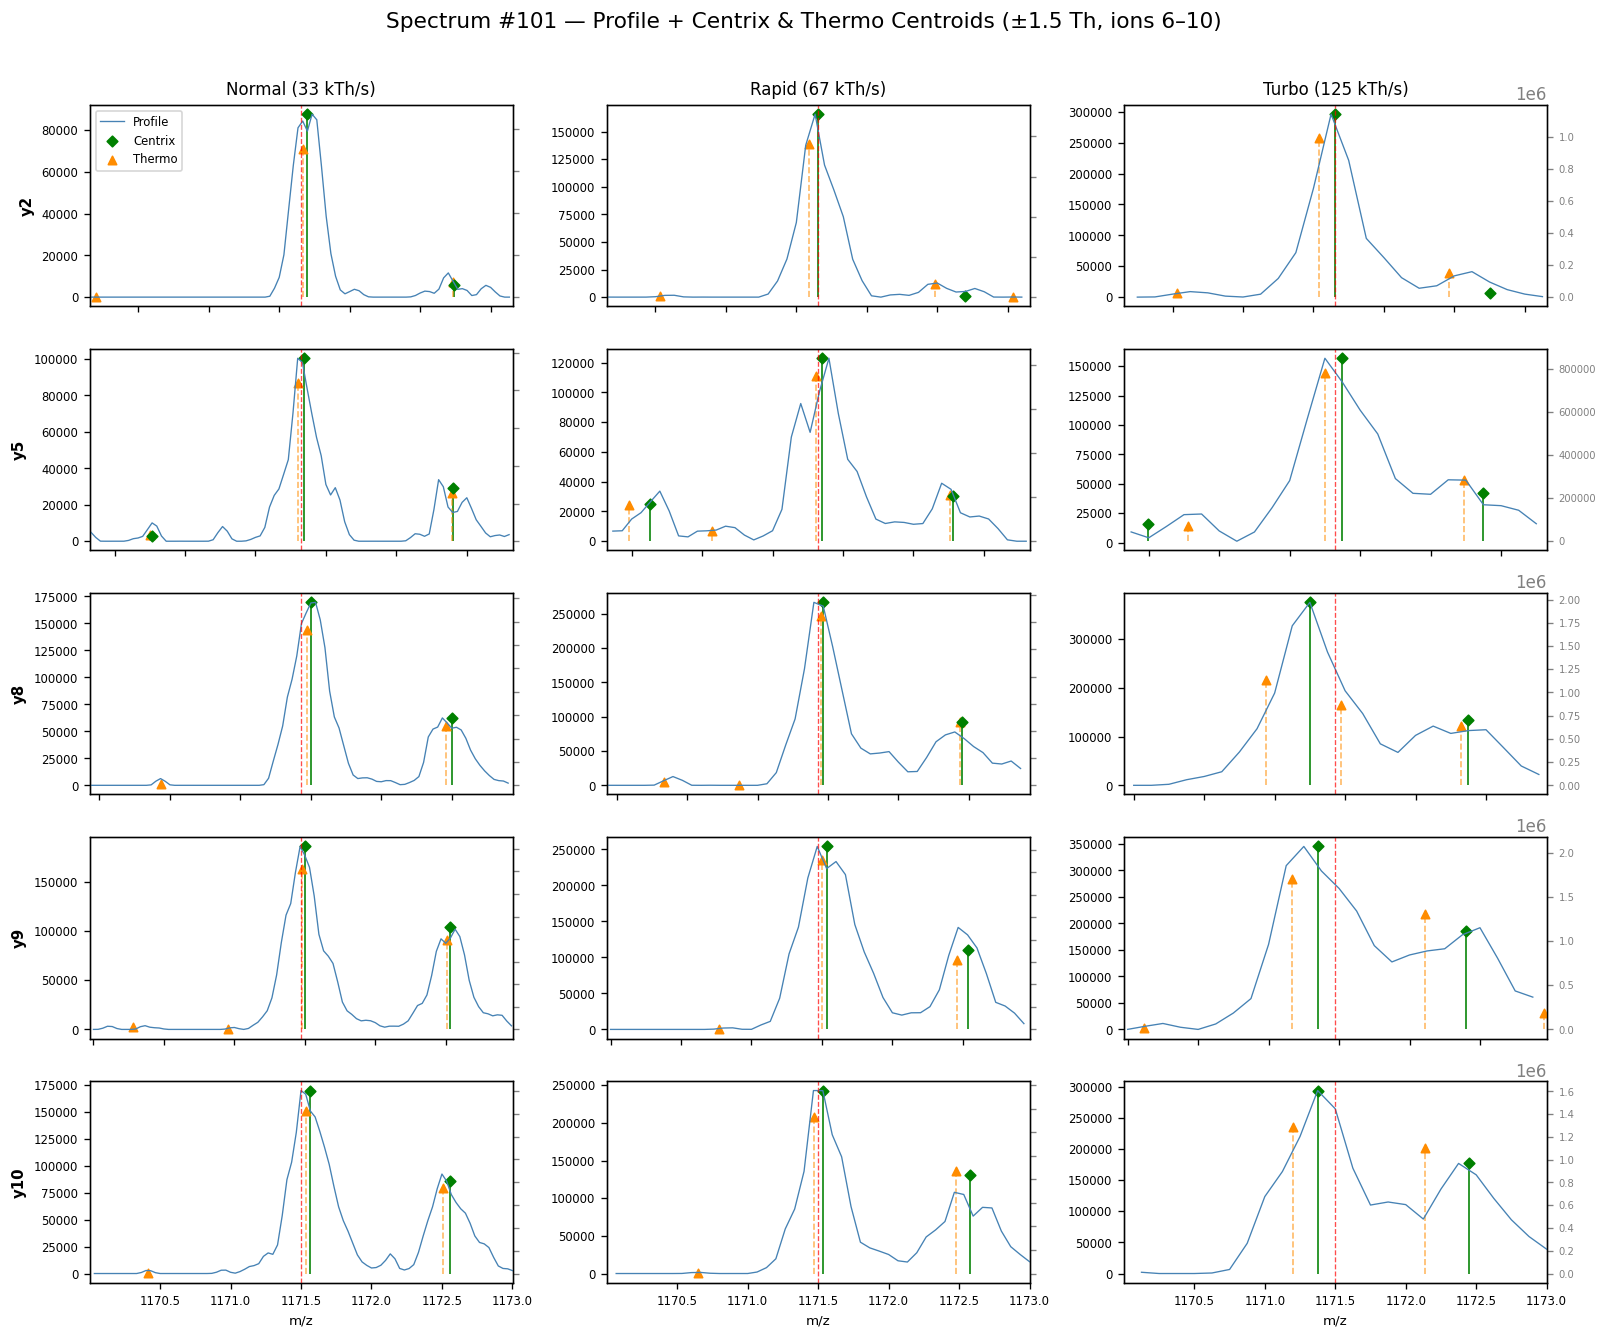

In [52]:
SCAN_IDX = 100  # 0-based index for spectrum #100
SCAN_NUM = SCAN_IDX + 1  # 1-based scan number for display
HALFWIDTH = 1.5  # ± Th around each ion
scan_labels = list(FILES.keys())
n_rates = len(scan_labels)

def plot_ion_group(ion_group, title_suffix):
    """Plot profile + centroid overlay for a group of ions."""
    n_ions = len(ion_group)
    fig, axes = plt.subplots(
        n_ions, n_rates,
        figsize=(4.5 * n_rates, 2.2 * n_ions),
        squeeze=False,
    )
    for col, label in enumerate(scan_labels):
        prof_mz, prof_int = load_spectrum(FILES[label]["profile"], SCAN_IDX)
        cx_mz, cx_int = load_spectrum(FILES[label]["centrix"], SCAN_IDX)
        th_mz, th_int = load_spectrum(FILES[label]["thermo"], SCAN_IDX)

        for row, (ion_name, theo_mz) in enumerate(ion_group.items()):
            ax = axes[row, col]
            ax2 = ax.twinx()

            # Profile trace (left axis)
            p_mz, p_int = crop(prof_mz, prof_int, theo_mz, HALFWIDTH)
            ax.plot(p_mz, p_int, color="steelblue", linewidth=0.8,
                    label="Profile" if row == 0 and col == 0 else None)
            ax.set_zorder(1)
            ax.patch.set_visible(False)

            # Centrix centroids (right axis)
            c_mz, c_int = crop(cx_mz, cx_int, theo_mz, HALFWIDTH)
            if len(c_mz) > 0:
                ax2.vlines(c_mz, 0, c_int, colors="green", linewidth=1.2, alpha=0.8)
                ax2.scatter(c_mz, c_int, marker="D", color="green", s=20, zorder=5,
                            label="Centrix" if row == 0 and col == 0 else None)

            # Thermo centroids (right axis)
            t_mz, t_int = crop(th_mz, th_int, theo_mz, HALFWIDTH)
            if len(t_mz) > 0:
                ax2.vlines(t_mz, 0, t_int, colors="darkorange", linewidth=1.0, alpha=0.6, linestyle="--")
                ax2.scatter(t_mz, t_int, marker="^", color="darkorange", s=25, zorder=4,
                            label="Thermo" if row == 0 and col == 0 else None)

            # Theoretical m/z line
            ax.axvline(theo_mz, color="red", linestyle="--", linewidth=0.8, alpha=0.7)

            ax.set_xlim(theo_mz - HALFWIDTH, theo_mz + HALFWIDTH)
            ax2.set_xlim(theo_mz - HALFWIDTH, theo_mz + HALFWIDTH)

            if col == 0:
                ax.set_ylabel(ion_name, fontsize=9, fontweight="bold")
            if row == 0:
                ax.set_title(label, fontsize=10)
                if col == 0:
                    h1, l1 = ax.get_legend_handles_labels()
                    h2, l2 = ax2.get_legend_handles_labels()
                    ax.legend(h1 + h2, l1 + l2, fontsize=7, loc="upper left")
            if row < n_ions - 1:
                ax.set_xticklabels([])
            else:
                ax.set_xlabel("m/z", fontsize=8)
            ax.tick_params(labelsize=7)
            ax2.tick_params(labelsize=6, colors="gray")
            if col < n_rates - 1:
                ax2.set_yticklabels([])

    fig.suptitle(f"Spectrum #{SCAN_NUM} — Profile + Centrix & Thermo Centroids (±1.5 Th, {title_suffix})",
                 fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()

plot_ion_group(top5, "top 5 ions")
plot_ion_group(next5, "ions 6–10")

## 2. Δm/z Violin Plots (All Spectra) — Centrix vs Thermo

For each theoretical b/y ion, we find the nearest centroid within
0.5 Th across **all spectra** and compute Δm/z = observed − theoretical.

Side-by-side violins compare **Centrix** (blue) and **Thermo** (orange) centroiding.
One plot per scan rate.

In [48]:
def compute_delta_mz_all_spectra(centrix_path, ions, tol=0.5):
    """
    For each ion, find the nearest centroid within `tol` across all spectra.
    Returns dict: ion_name -> array of delta_mz values.
    """
    deltas = {name: [] for name in ions}
    reader = mzml.MzML(str(centrix_path))
    for spec in reader:
        mz_arr = spec["m/z array"]
        int_arr = spec["intensity array"]
        for name, theo_mz in ions.items():
            obs_mz, _ = nearest_centroid(mz_arr, int_arr, theo_mz, tol)
            if obs_mz is not None:
                deltas[name].append(obs_mz - theo_mz)
    return deltas

# Compute for all three scan rates — both Centrix and Thermo (using top 10 ions)
all_deltas_centrix = {}
all_deltas_thermo = {}
for label, paths in FILES.items():
    print(f"Processing Centrix {label}...")
    all_deltas_centrix[label] = compute_delta_mz_all_spectra(paths["centrix"], top10)
    print(f"Processing Thermo  {label}...")
    all_deltas_thermo[label] = compute_delta_mz_all_spectra(paths["thermo"], top10)
print("Done.")

Processing Centrix Normal (33 kTh/s)...
Processing Thermo  Normal (33 kTh/s)...
Processing Centrix Rapid (67 kTh/s)...
Processing Thermo  Rapid (67 kTh/s)...
Processing Centrix Turbo (125 kTh/s)...
Processing Thermo  Turbo (125 kTh/s)...
Done.


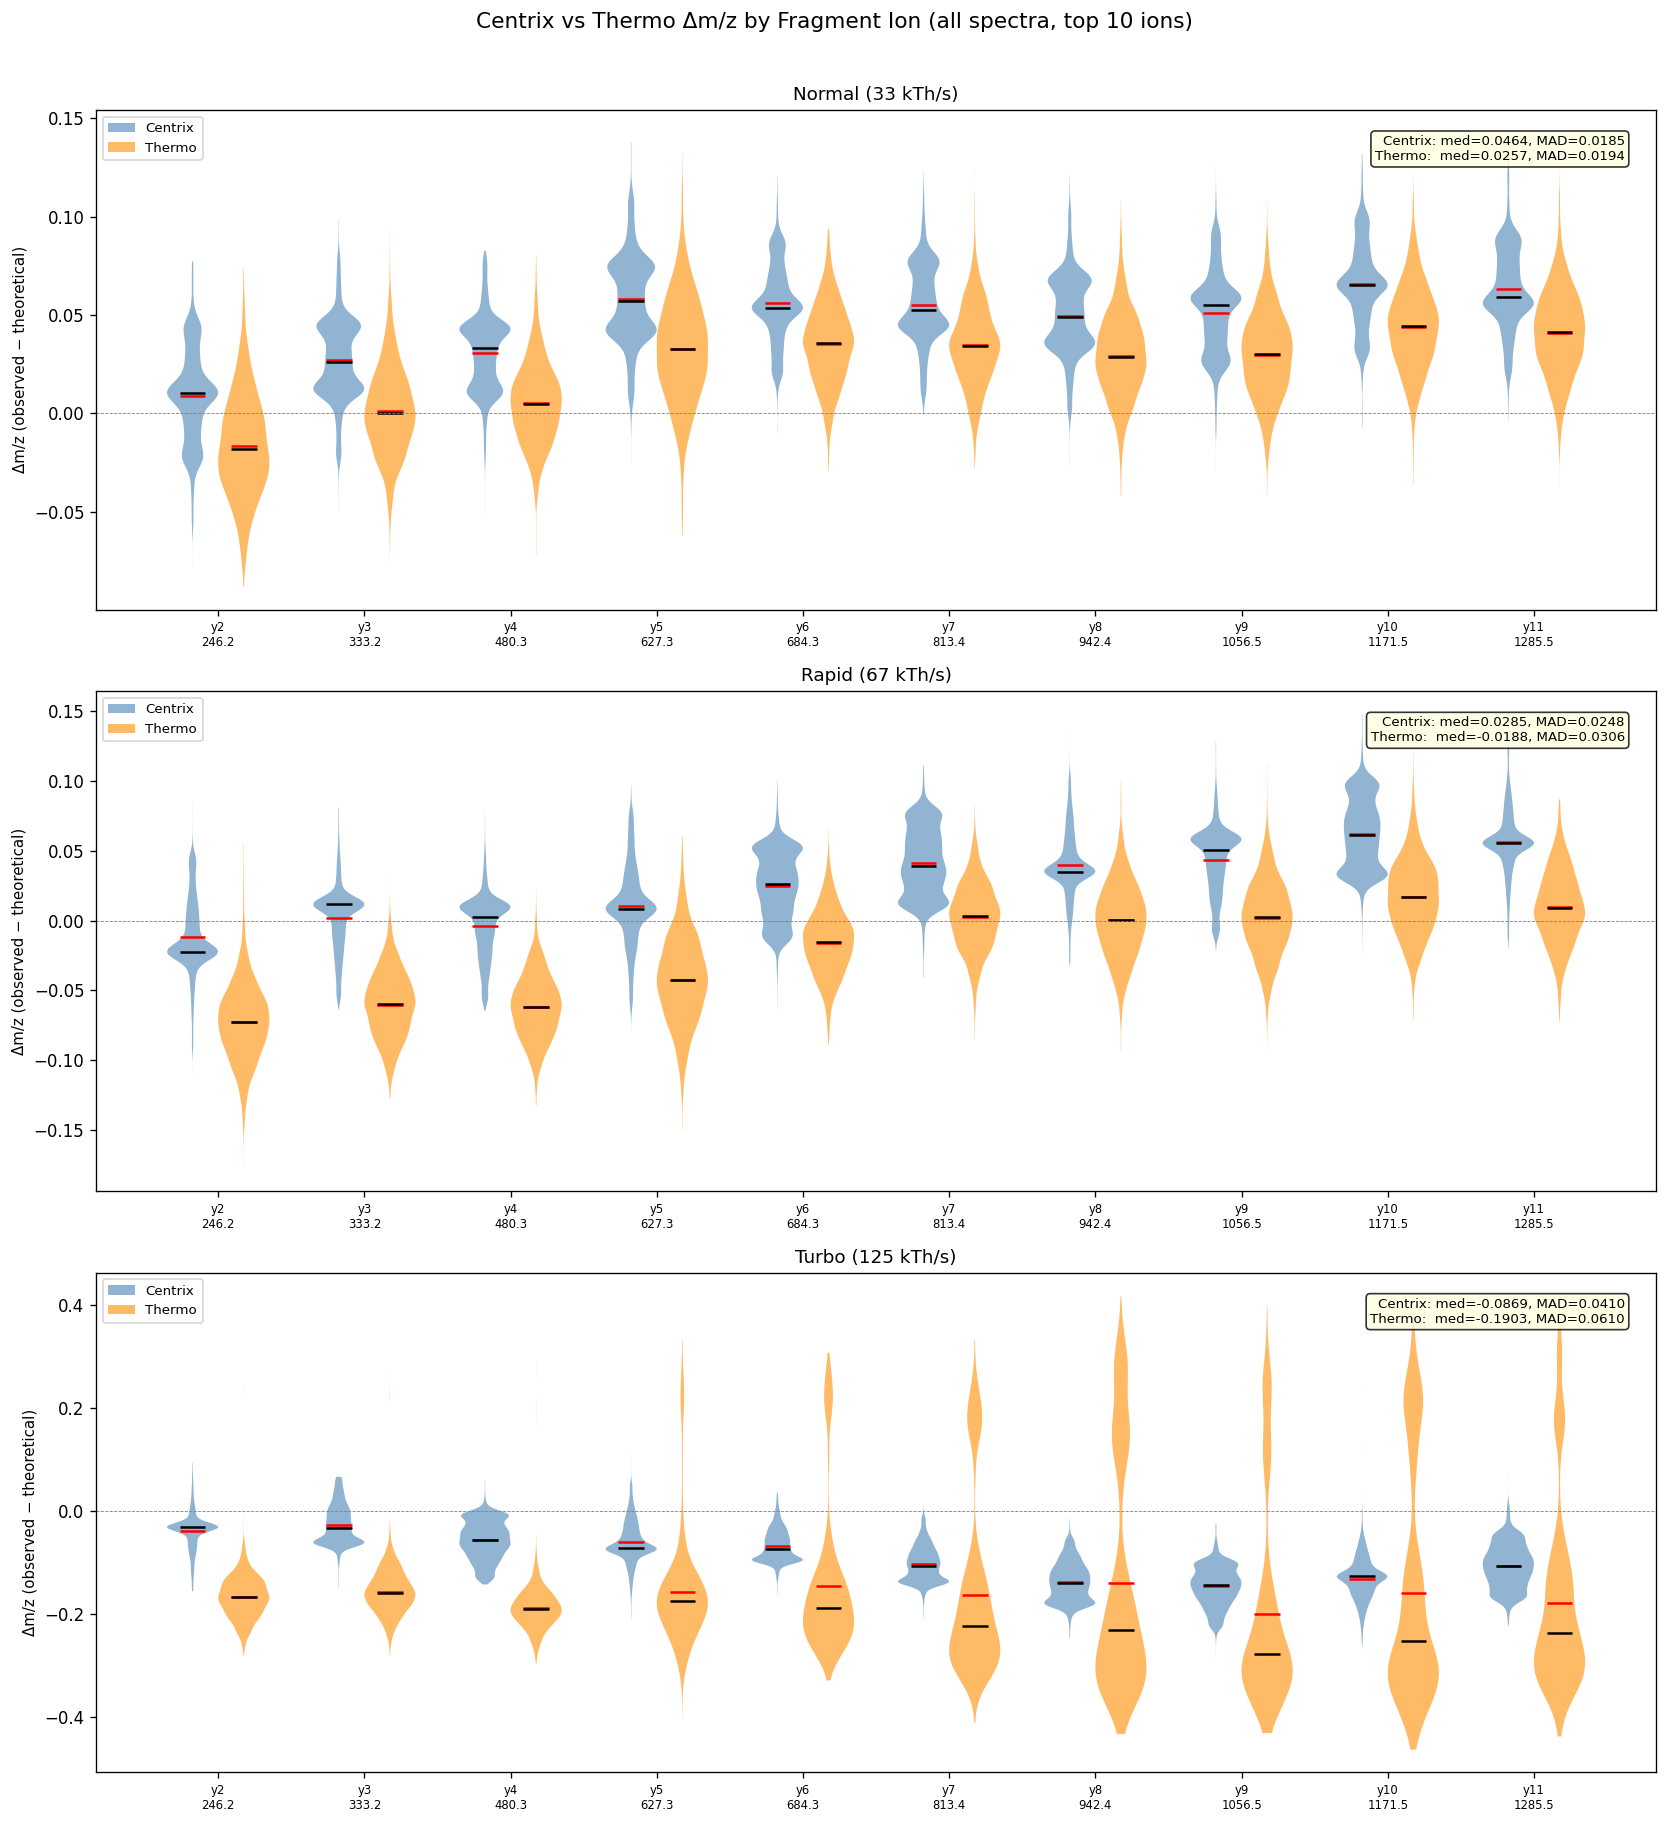

In [49]:
ion_names = list(top10.keys())
ion_mzs = [top10[n] for n in ion_names]
ion_labels = [f"{n}\n{mz:.1f}" for n, mz in zip(ion_names, ion_mzs)]

scan_labels = list(FILES.keys())
fig, axes = plt.subplots(len(scan_labels), 1, figsize=(14, 5 * len(scan_labels)), squeeze=False)

WIDTH = 0.35  # half-width offset for side-by-side violins

for i, label in enumerate(scan_labels):
    ax = axes[i, 0]
    cx_deltas = all_deltas_centrix[label]
    th_deltas = all_deltas_thermo[label]

    # Build paired data
    cx_data, th_data = [], []
    cx_pos, th_pos = [], []
    for j, name in enumerate(ion_names):
        cd = np.array(cx_deltas[name])
        td = np.array(th_deltas[name])
        if len(cd) > 0:
            cx_data.append(cd)
            cx_pos.append(j - WIDTH / 2)
        if len(td) > 0:
            th_data.append(td)
            th_pos.append(j + WIDTH / 2)

    # Centrix violins (blue)
    if cx_data:
        vp_cx = ax.violinplot(cx_data, positions=cx_pos, widths=WIDTH,
                              showmeans=True, showmedians=True, showextrema=False)
        for pc in vp_cx["bodies"]:
            pc.set_facecolor("steelblue")
            pc.set_alpha(0.6)
        vp_cx["cmeans"].set_color("red")
        vp_cx["cmedians"].set_color("black")

    # Thermo violins (orange)
    if th_data:
        vp_th = ax.violinplot(th_data, positions=th_pos, widths=WIDTH,
                              showmeans=True, showmedians=True, showextrema=False)
        for pc in vp_th["bodies"]:
            pc.set_facecolor("darkorange")
            pc.set_alpha(0.6)
        vp_th["cmeans"].set_color("red")
        vp_th["cmedians"].set_color("black")

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
    ax.set_xticks(range(len(ion_names)))
    ax.set_xticklabels(ion_labels, fontsize=7)
    ax.set_ylabel("Δm/z (observed − theoretical)", fontsize=9)
    ax.set_title(f"{label}", fontsize=11)

    # Legend
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor="steelblue", alpha=0.6, label="Centrix"),
                       Patch(facecolor="darkorange", alpha=0.6, label="Thermo")],
              fontsize=8, loc="upper left")

    # Summary stats in text box
    cx_all = np.concatenate([np.array(cx_deltas[n]) for n in ion_names if len(cx_deltas[n]) > 0])
    th_all = np.concatenate([np.array(th_deltas[n]) for n in ion_names if len(th_deltas[n]) > 0])
    stats_text = ""
    if len(cx_all) > 0:
        stats_text += f"Centrix: med={np.median(cx_all):.4f}, MAD={np.median(np.abs(cx_all - np.median(cx_all))):.4f}\n"
    if len(th_all) > 0:
        stats_text += f"Thermo:  med={np.median(th_all):.4f}, MAD={np.median(np.abs(th_all - np.median(th_all))):.4f}"
    ax.text(0.98, 0.95, stats_text.strip(),
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

fig.suptitle("Centrix vs Thermo Δm/z by Fragment Ion (all spectra, top 10 ions)", fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## 3. Summary Statistics — Centrix vs Thermo

Per-ion and overall Δm/z statistics for each scan rate, comparing Centrix and Thermo centroiding.

In [50]:
for label in FILES:
    cx_deltas = all_deltas_centrix[label]
    th_deltas = all_deltas_thermo[label]
    print(f"\n{'='*90}")
    print(f"{label}")
    print(f"{'='*90}")
    print(f"{'':>5s}  {'':>9s}  {'--- Centrix ---':^27s}  {'--- Thermo ---':^27s}")
    print(f"{'Ion':>5s}  {'m/z':>9s}  {'N':>5s}  {'Median Δ':>9s}  {'Mean Δ':>9s}  {'N':>5s}  {'Median Δ':>9s}  {'Mean Δ':>9s}")
    print(f"{'-'*5:>5s}  {'-'*9:>9s}  {'-'*5:>5s}  {'-'*9:>9s}  {'-'*9:>9s}  {'-'*5:>5s}  {'-'*9:>9s}  {'-'*9:>9s}")
    all_cx, all_th = [], []
    for name in ion_names:
        cd = np.array(cx_deltas[name])
        td = np.array(th_deltas[name])
        cx_str = f"{len(cd):5d}  {np.median(cd):+9.4f}  {np.mean(cd):+9.4f}" if len(cd) > 0 else f"{'—':>5s}  {'':>9s}  {'':>9s}"
        th_str = f"{len(td):5d}  {np.median(td):+9.4f}  {np.mean(td):+9.4f}" if len(td) > 0 else f"{'—':>5s}  {'':>9s}  {'':>9s}"
        print(f"{name:>5s}  {top10[name]:9.4f}  {cx_str}  {th_str}")
        all_cx.extend(cd)
        all_th.extend(td)

    # Totals
    cx_arr = np.array(all_cx) if all_cx else np.array([])
    th_arr = np.array(all_th) if all_th else np.array([])
    print(f"{'-'*90}")
    cx_tot = f"{len(cx_arr):5d}  {np.median(cx_arr):+9.4f}  {np.mean(cx_arr):+9.4f}" if len(cx_arr) > 0 else ""
    th_tot = f"{len(th_arr):5d}  {np.median(th_arr):+9.4f}  {np.mean(th_arr):+9.4f}" if len(th_arr) > 0 else ""
    print(f"{'TOTAL':>5s}  {'':>9s}  {cx_tot}  {th_tot}")
    if len(cx_arr) > 0 and len(th_arr) > 0:
        cx_mad = np.median(np.abs(cx_arr - np.median(cx_arr)))
        th_mad = np.median(np.abs(th_arr - np.median(th_arr)))
        print(f"{'MAD':>5s}  {'':>9s}  {'':>5s}  {cx_mad:+9.4f}  {'':>9s}  {'':>5s}  {th_mad:+9.4f}")


Normal (33 kTh/s)
                        --- Centrix ---              --- Thermo ---       
  Ion        m/z      N   Median Δ     Mean Δ      N   Median Δ     Mean Δ
-----  ---------  -----  ---------  ---------  -----  ---------  ---------
   y2   246.1561   2000    +0.0106    +0.0088   2000    -0.0182    -0.0166
   y3   333.1881   2000    +0.0260    +0.0269   2000    +0.0002    +0.0011
   y4   480.2565   2000    +0.0334    +0.0308   2000    +0.0048    +0.0051
   y5   627.3249   2000    +0.0573    +0.0581   2000    +0.0326    +0.0326
   y6   684.3464   2000    +0.0536    +0.0562   2000    +0.0357    +0.0354
   y7   813.3890   2000    +0.0524    +0.0553   2000    +0.0343    +0.0346
   y8   942.4316   2000    +0.0488    +0.0497   2000    +0.0286    +0.0294
   y9  1056.4745   2000    +0.0552    +0.0513   2000    +0.0301    +0.0299
  y10  1171.5014   2000    +0.0653    +0.0657   2000    +0.0444    +0.0439
  y11  1285.5444   2000    +0.0592    +0.0632   2000    +0.0414    +0.0410
------